In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2


In [ ]:
kT = pd.read_csv('../fullkTOutput.csv')
#our nu don't match the frequencies of the actual image because all of those values are in the tetrad frame
print(kT.head())

        r   theta      phi            kT            nu           exp  \
0  38.411  2.5474  4.64309  1.537230e-11  9.062250e+12  9.961010e-01   
1  38.411  2.5474  4.64309  1.537230e-11  2.521630e+14  8.970060e-01   
2  38.411  2.5474  4.64309  1.537230e-11  7.016570e+15  4.858560e-02   
3  38.411  2.5474  4.64309  1.537230e-11  1.952400e+17  2.826820e-37   
4  38.411  2.5474  4.64309  1.537230e-11  5.432680e+18  0.000000e+00   

          coeff  
0  8.496090e-21  
1  7.650870e-21  
2  4.144030e-22  
3  2.411090e-57  
4  0.000000e+00  


In [7]:
hf = np.load('../output/temp_free_tde.npz')
print(["{0:e}".format(i) for i in list(hf['frequency'])])

['3.300000e+09', '9.182446e+10', '2.555070e+12', '7.109634e+13', '1.978298e+15', '5.504732e+16', '1.531724e+18', '4.262114e+19', '1.185959e+21', '3.300000e+22']


In [11]:
kT['frequency'] = hf['frequency'][np.argmin(abs(kT['nu'].values[:,None] - hf['frequency']), axis=1)]
print(kT.head())

        r   theta      phi            kT            nu           exp  \
0  38.411  2.5474  4.64309  1.537230e-11  9.062250e+12  9.961010e-01   
1  38.411  2.5474  4.64309  1.537230e-11  2.521630e+14  8.970060e-01   
2  38.411  2.5474  4.64309  1.537230e-11  7.016570e+15  4.858560e-02   
3  38.411  2.5474  4.64309  1.537230e-11  1.952400e+17  2.826820e-37   
4  38.411  2.5474  4.64309  1.537230e-11  5.432680e+18  0.000000e+00   

          coeff     frequency  
0  8.496090e-21  2.555070e+12  
1  7.650870e-21  7.109634e+13  
2  4.144030e-22  1.978298e+15  
3  2.411090e-57  5.504732e+16  
4  0.000000e+00  1.531724e+18  


In [18]:
kT=kT[~np.isnan(kT['coeff'])]

In [ ]:
#note that it's weird that there's only 77 non-Nan frequency one values but that might be because of the super super low freq

In [22]:
band1 = kT[kT['frequency']==hf['frequency'][1]]

In [24]:
print(np.std(band1['nu'])/hf['frequency'][1])

4.065179337479049


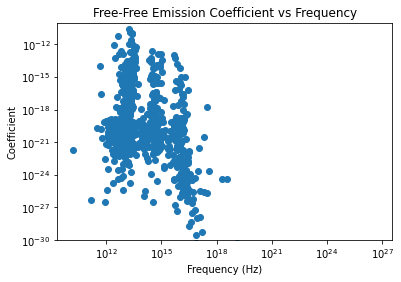

In [26]:
plt.scatter(kT['nu'][::500],kT['coeff'][::500])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Coefficient')
plt.title('Free-Free Emission Coefficient vs Frequency')
plt.ylim(1e-30,1e-10)
plt.show()

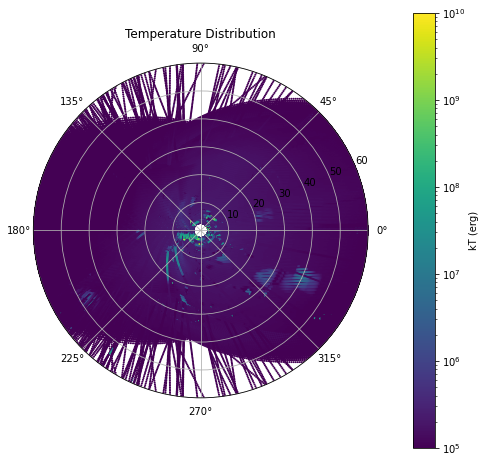

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={'projection': 'polar'})
ax.scatter(kT['phi'], kT['r'], c=kT['kT']/kB, s=1, norm=LogNorm(vmin=1e5, vmax=1e10))
ax.grid(True)
ax.set_rmax(60)
cbar = plt.colorbar(ax.collections[0], ax=ax, pad=0.1)
cbar.set_label('kT (erg)')
ax.set_title('Temperature Distribution')
plt.show()

In [3]:
kT['x'] = kT['r'] * np.sin(kT['th']) * np.cos(kT['phi'])
kT['y'] = kT['r'] * np.sin(kT['th']) * np.sin(kT['phi'])
kT['z'] = kT['r'] * np.cos(kT['th'])

coords = np.array([kT['x'], kT['y'], kT['z']]).T
x = coords.astype(np.float32)
print(x.shape)

(2406616, 3)


In [14]:
x[kT['kT']/kB > 1e8].shape

(5008, 3)

In [20]:

plt_points = k3d.points(positions=x[::1000],
                        point_size=2.0,
                        shader='flat',
                        opacity=0.7,
                        color_map=matplotlib_color_maps.Hot,
                        attribute=np.log10(kT['kT'][::1000]/kB),
                        color_range=[5, 10])

plot = k3d.plot()
plot += plt_points
plot.snapshot_type = 'online'
plot.display()  


data = plot.get_snapshot()

with open('./wholeRegion.html', 'w') as f:
    f.write(data)

Output()

In [10]:

from IPython.display import display, HTML
plot.snapshot_type = 'inline'
HTML(plot.get_snapshot())

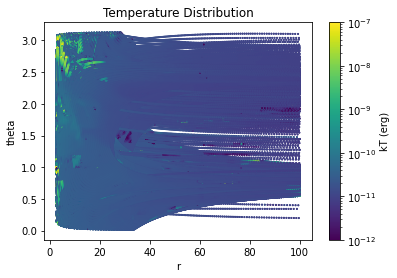

In [6]:
plt.scatter(kT['r'], kT['th'], c=kT['kT'], s=1, norm=LogNorm(vmin=1e-12, vmax=1e-7))
plt.colorbar(label='kT (erg)')
plt.xlabel('r')
plt.ylabel('theta')
plt.title('Temperature Distribution')
plt.show()

In [2]:

with h5py.File('../data/tde_multigroup_example.athdf', 'r') as f:
     variable_names = np.array([x.decode('ascii', 'replace')
                                   for x in f.attrs['VariableNames'][:]])
print(variable_names)

['rho' 'press' 'vel1' 'vel2' 'vel3' 'Er_0' 'Fr_0_1' 'Fr_0_2' 'Fr_0_3'
 'Pr_0_11' 'Pr_0_22' 'Pr_0_33' 'Pr_0_12' 'Pr_0_13' 'Pr_0_23' 'Pr_0_21'
 'Pr_0_31' 'Pr_0_32' 'Er0_0' 'Fr0_0_1' 'Fr0_0_2' 'Fr0_0_3' 'Er_1' 'Fr_1_1'
 'Fr_1_2' 'Fr_1_3' 'Pr_1_11' 'Pr_1_22' 'Pr_1_33' 'Pr_1_12' 'Pr_1_13'
 'Pr_1_23' 'Pr_1_21' 'Pr_1_31' 'Pr_1_32' 'Er0_1' 'Fr0_1_1' 'Fr0_1_2'
 'Fr0_1_3' 'Er_2' 'Fr_2_1' 'Fr_2_2' 'Fr_2_3' 'Pr_2_11' 'Pr_2_22' 'Pr_2_33'
 'Pr_2_12' 'Pr_2_13' 'Pr_2_23' 'Pr_2_21' 'Pr_2_31' 'Pr_2_32' 'Er0_2'
 'Fr0_2_1' 'Fr0_2_2' 'Fr0_2_3' 'Er_3' 'Fr_3_1' 'Fr_3_2' 'Fr_3_3' 'Pr_3_11'
 'Pr_3_22' 'Pr_3_33' 'Pr_3_12' 'Pr_3_13' 'Pr_3_23' 'Pr_3_21' 'Pr_3_31'
 'Pr_3_32' 'Er0_3' 'Fr0_3_1' 'Fr0_3_2' 'Fr0_3_3' 'Er_4' 'Fr_4_1' 'Fr_4_2'
 'Fr_4_3' 'Pr_4_11' 'Pr_4_22' 'Pr_4_33' 'Pr_4_12' 'Pr_4_13' 'Pr_4_23'
 'Pr_4_21' 'Pr_4_31' 'Pr_4_32' 'Er0_4' 'Fr0_4_1' 'Fr0_4_2' 'Fr0_4_3'
 'Er_5' 'Fr_5_1' 'Fr_5_2' 'Fr_5_3' 'Pr_5_11' 'Pr_5_22' 'Pr_5_33' 'Pr_5_12'
 'Pr_5_13' 'Pr_5_23' 'Pr_5_21' 'Pr_5_31' 'Pr_5_32' 'Er0_5' 'Fr0_5_1'

In [2]:
temp = h5py.File('../data/tdestream.out1.00600.athdf', 'r')

In [18]:
arguments = {'data_file': '../data/tdestream.out1.00600.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.5, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)

(512, 1024)


In [19]:
arguments = {'data_file': '../data/tdestream.out1.00600.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.5, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)

(512, 1024)


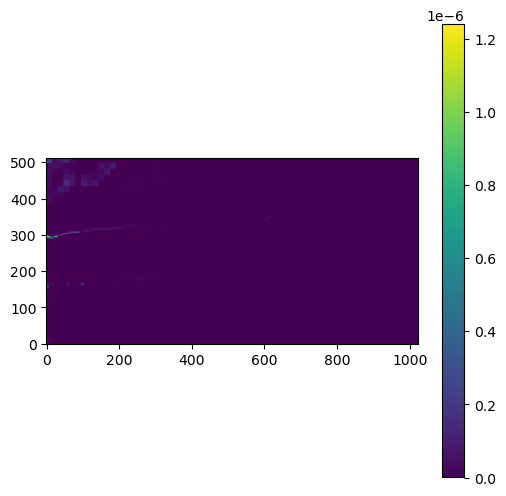

In [21]:
temp = T0 * press / (rho)
plt.imshow(temp,origin='lower')
plt.colorbar()
plt.show()

In [6]:
variable_names = np.array([x.decode('ascii', 'replace')
                                   for x in temp.attrs['VariableNames'][:]])

In [8]:
print(variable_names)

['rho' 'press' 'vel1' 'vel2' 'vel3' 'Er' 'Fr1' 'Fr2' 'Fr3' 'Pr11' 'Pr22'
 'Pr33' 'Pr12' 'Pr13' 'Pr23' 'Pr21' 'Pr31' 'Pr32' 'Er0' 'Fr01' 'Fr02'
 'Fr03' 'Sigma_s_0' 'Sigma_a_0' 'Sigma_p_0' 'Bcc1' 'Bcc2' 'Bcc3']


In [13]:
list(temp['prim'].shape)

[25, 83231, 8, 4, 8]

In [ ]:
press = temp['prim'][1]

In [2]:
print(h*2.3e11)

1.5239961345e-15


In [3]:
default_args = {}
default_args['figsize'] = (4,4)
default_args['filename_data'] = '../output/example_free_free_tde.npz'
default_args['filename_plot'] = None
default_args['stokes_q'] = False
default_args['stokes_u'] = False
default_args['stokes_v'] = False
default_args['name'] = None
default_args['frequency_num'] = None
default_args['refinement_level'] = False
default_args['width'] = None
default_args['mass'] = None
default_args['distance'] = None
default_args['axes'] = None
default_args['max_level'] = None
default_args['vmin'] = None
default_args['vmax'] = None
default_args['cmap'] = None
default_args['notex'] = False
default_args['fontsize'] = None

In [18]:
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["figure.dpi"] = 100

In [5]:
temp=(100*G*Mbh/c**2)*u.cgs.cm
print(temp)
print(temp.to(u.pc))

44298751141503.734 cm
1.4356247524763523e-05 pc


In [8]:
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit

print(T0)

2.2549164239776884e-10


In [9]:
v0**2

224688794684204.4

In [16]:
free = np.load('../output/example_free_tde.npz')
hf = np.load('../output/temp_free_tde.npz')
sync = np.load('../output/example_tde.npz')
hs = np.load('../output/highfreq_tde.npz')

In [8]:
print(list(hf['frequency']))

[330000000000.0, 1978298026052.5085, 11859585090555.266, 71096344771052.0, 426211389454912.94, 2555070152847722.0, 1.5317243150922158e+16, 9.182446027283552e+16, 5.5047317727601683e+17, 3.3e+18]


In [6]:
multi = h5py.File('../data/tde_multigroup_example.athdf', 'r')

In [ ]:
temp

ValuesViewHDF5(<HDF5 file "tde_multigroup_example.athdf" (mode r)>)

In [10]:
print(list(multi['prim'].keys()))

AttributeError: 'Dataset' object has no attribute 'keys'

In [ ]:
print(file['prim'].shape)
#the 325 is for the different prims that we have
#the 5244 seems to match our grid based on the LogicalLocations 

(325, 5244, 8, 4, 8)


In [15]:
print(free['I_nu'].shape)

(64, 64)


In [7]:
print(list(hf.keys()))

['mass_msun', 'width', 'frequency', 'adaptive_num_levels', 'I_nu', 'emission', 'tau']


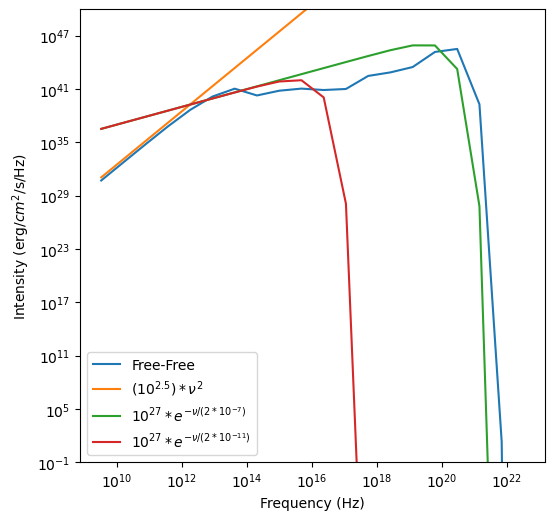

In [19]:
frequencies = np.array(hf['frequency'])
iNu = []
for freq in range(len(frequencies)):
    iNu.append(np.sum(hf['I_nu'][freq][~np.isnan(hf['I_nu'][freq])]))
plt.plot(frequencies, frequencies*iNu, label='Free-Free')
plt.plot(frequencies, frequencies*(10**2.5)*frequencies**2, label=r"$(10^{2.5})*\nu^2$")
plt.plot(frequencies, frequencies*1e27*np.exp(-frequencies*h/(2e-7)), label=r"$10^{27}*e^{-\nu/(2*10^{-7})}$")
plt.plot(frequencies, frequencies*1e27*np.exp(-frequencies*h/(2e-11)), label=r"$10^{27}*e^{-\nu/(2*10^{-11})}$")

#plt.plot(frequencies, 1e54*(np.exp(-frequencies*h/(2e-11)))/(frequencies**2), label=r"$10^{27}*(1-e^{-\nu/(2*10^{-11})})/\nu^3$")
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (Hz)')
plt.ylim(1e-1, 1e50)
plt.ylabel('Intensity (erg/$cm^2$/s/Hz)')
plt.legend()
plt.show()

In [58]:
h

6.62607015e-27

In [56]:
(2*1e-11)/h

3018380359284303.5

In [30]:
frequencies

array([3.30000000e+09, 9.26381347e+09, 2.60055273e+10, 7.30031376e+10,
       2.04935591e+11, 5.75298511e+11, 1.61498730e+12, 4.53361853e+12,
       1.27268474e+13, 3.57270122e+13, 1.00293448e+14, 2.81545391e+14,
       7.90358785e+14, 2.21870799e+15, 6.22839301e+15, 1.74844458e+16,
       4.90826195e+16, 1.37785525e+17, 3.86793758e+17, 1.08581371e+18,
       3.04811383e+18, 8.55671453e+18, 2.40205477e+19, 6.74308707e+19,
       1.89293033e+20, 5.31386469e+20, 1.49171671e+21, 4.18757131e+21,
       1.17554180e+22, 3.30000000e+22])

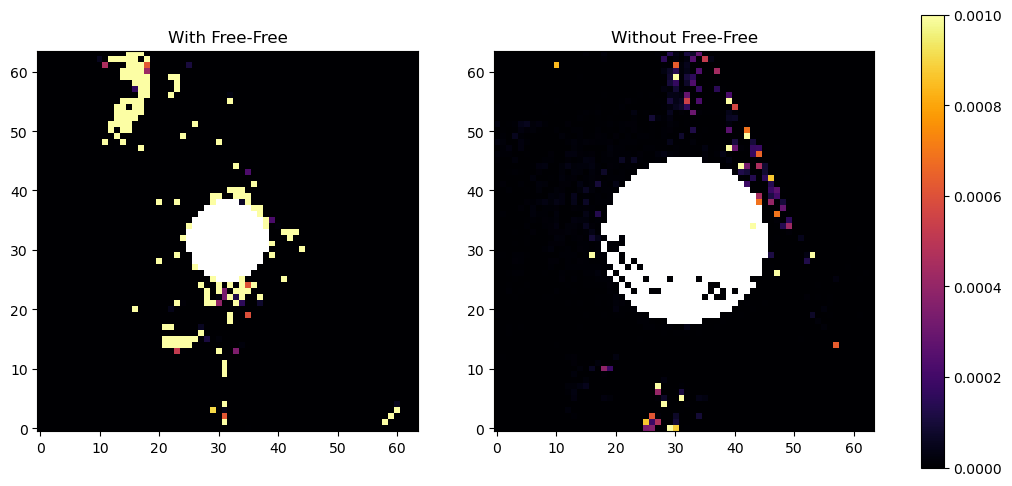

In [42]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(hf['I_nu'][15], cmap='inferno', origin='lower',vmax=1e15)
ax[1].imshow(hs['I_nu'][0], cmap='inferno', origin='lower',vmax=1e-3)
ax[0].set_title('With Free-Free')
ax[1].set_title('Without Free-Free')
plt.colorbar(ax[1].images[0], ax=ax, fraction=0.05)
plt.show()

In [24]:
free['I_nu'][32,32]

8.411915668450402e-08

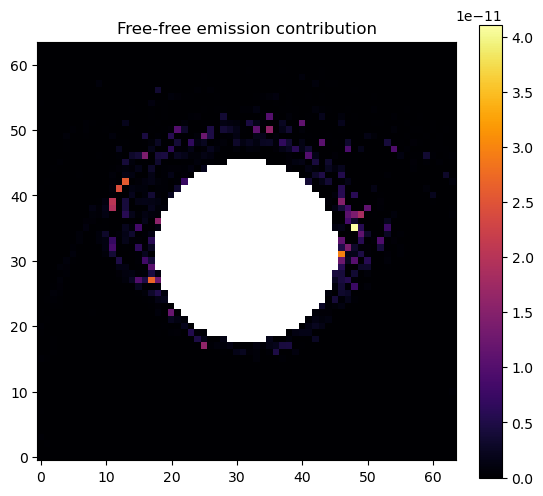

In [8]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['emission']-hs['emission'], cmap='inferno', origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Free-free emission contribution')
plt.show()

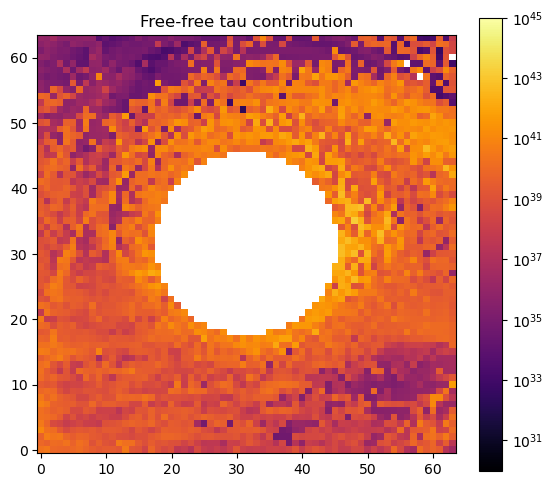

In [9]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['tau']-hs['tau'], cmap='inferno', origin='lower',norm=LogNorm(vmin=1e30, vmax=1e45))
plt.colorbar(fraction=0.05)
plt.title('Free-free tau contribution')
plt.show()

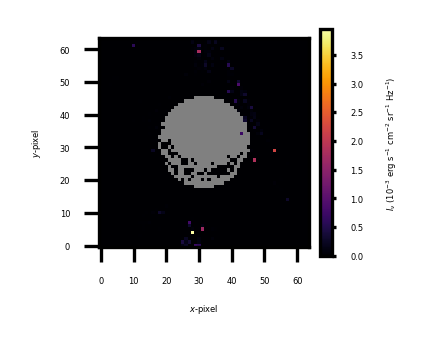

In [6]:
default_args['fontsize'] = (2)
default_args['figsize'] = (1,1)

fig,ax = utils.plot_data(**default_args)
#ax.margins(x=0,y=0)
plt.show()